## Mounting Google Drive

In this step, we connect Google Colab to Google Drive to access the dataset files. This allows us to load and save data directly from our Drive storage.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Extracting the Dataset

In this step, the compressed dataset file is extracted from Google Drive into the Colab environment. This allows direct access to the image files for preprocessing and training.

In [2]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/archive.zip"
extract_path = "/content/archive"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped Done ✔️")

Unzipped Done ✔️


## Exploring Dataset Structure

In this step, we inspect the contents of the extracted dataset directory to understand its structure. This helps verify that all required files and folders (such as Train, Test, and Meta) are correctly loaded.

In [3]:
base_path = "/content/archive"

print(os.listdir(base_path))

['Meta', 'Test.csv', 'meta', 'Train', 'Meta.csv', 'Train.csv', 'Test', 'train', 'test']


## Inspecting Training Class Folders

In this step, we explore the training directory to view the class folders. Each folder represents a different traffic sign category, labeled by its class ID.

In [4]:
print(os.listdir("/content/archive/Train")[:10])

['8', '39', '11', '6', '28', '0', '23', '27', '20', '9']


## Defining Training Data Path

In this step, we define the path to the original training dataset directory. This path will be used later to access and organize the image data for model training.

In [5]:
original_train = "/content/archive/Train"

## Preparing Dataset: Train and Validation Split

In this step, the original dataset is reorganized into a structure suitable for YOLOv8 classification.  
The data is split into two subsets:

- **Training set (80%)**: used to train the model  
- **Validation set (20%)**: used to evaluate model performance  

Each class folder is processed separately to ensure a balanced distribution of images across both sets.

In [6]:
import shutil
import random

original_train = "/content/archive/Train"

dataset_path = "/content/archive_dataset"

train_path = os.path.join(dataset_path, "train")
val_path = os.path.join(dataset_path, "val")

os.makedirs(train_path, exist_ok=True)
os.makedirs(val_path, exist_ok=True)

for class_id in os.listdir(original_train):

    src_folder = os.path.join(original_train, class_id)

    train_class_folder = os.path.join(train_path, class_id)
    val_class_folder = os.path.join(val_path, class_id)

    os.makedirs(train_class_folder, exist_ok=True)
    os.makedirs(val_class_folder, exist_ok=True)

    images = os.listdir(src_folder)
    random.shuffle(images)

    split = int(0.8 * len(images))

    for img in images[:split]:
        shutil.copy(os.path.join(src_folder, img),
                    os.path.join(train_class_folder, img))

    for img in images[split:]:
        shutil.copy(os.path.join(src_folder, img),
                    os.path.join(val_class_folder, img))

print("DONE dataset ready")

DONE dataset ready


## Visualizing Dataset Structure

In this step, we display the hierarchical structure of the prepared dataset.  
This helps verify that the data is correctly organized into training and validation folders, and that each class contains its corresponding images.

In [7]:
import os

def print_structure(path, indent=0):
    for item in os.listdir(path):
        item_path = os.path.join(path, item)
        print("  " * indent + "├── " + item)

        if os.path.isdir(item_path):
            print_structure(item_path, indent + 1)

dataset_path = r"/content/archive_dataset"

print_structure(dataset_path)

Streaming output truncated to the last 5000 lines.
    ├── 00014_00003_00026.png
    ├── 00014_00003_00024.png
    ├── 00014_00022_00011.png
    ├── 00014_00010_00002.png
    ├── 00014_00022_00000.png
    ├── 00014_00012_00017.png
    ├── 00014_00011_00028.png
    ├── 00014_00014_00004.png
    ├── 00014_00013_00014.png
    ├── 00014_00011_00003.png
    ├── 00014_00015_00007.png
    ├── 00014_00005_00013.png
    ├── 00014_00018_00002.png
    ├── 00014_00008_00001.png
    ├── 00014_00001_00002.png
    ├── 00014_00009_00026.png
    ├── 00014_00024_00012.png
    ├── 00014_00003_00007.png
    ├── 00014_00019_00000.png
    ├── 00014_00006_00029.png
    ├── 00014_00016_00028.png
    ├── 00014_00014_00017.png
    ├── 00014_00012_00014.png
    ├── 00014_00010_00016.png
    ├── 00014_00009_00003.png
    ├── 00014_00025_00026.png
    ├── 00014_00008_00028.png
    ├── 00014_00007_00010.png
    ├── 00014_00010_00011.png
    ├── 00014_00022_00002.png
    ├── 00014_00000_00009.png
    ├── 00014_00009

## Visualizing Sample Images from Each Class

In this step, we display one random image from each class in the training dataset.  
This helps us understand the visual differences between traffic sign categories and verify that the images are correctly loaded.

Additionally, we print the shape (dimensions) of each image to check whether all images have the same size.

Class 0 -> Shape: (54, 53, 3)
Class 1 -> Shape: (37, 38, 3)
Class 10 -> Shape: (67, 62, 3)
Class 11 -> Shape: (46, 49, 3)
Class 12 -> Shape: (49, 48, 3)
Class 13 -> Shape: (40, 40, 3)
Class 14 -> Shape: (106, 105, 3)
Class 15 -> Shape: (74, 68, 3)
Class 16 -> Shape: (28, 29, 3)
Class 17 -> Shape: (41, 41, 3)
Class 18 -> Shape: (61, 62, 3)
Class 19 -> Shape: (47, 50, 3)
Class 2 -> Shape: (118, 119, 3)
Class 20 -> Shape: (33, 33, 3)
Class 21 -> Shape: (96, 108, 3)
Class 22 -> Shape: (32, 33, 3)
Class 23 -> Shape: (28, 27, 3)
Class 24 -> Shape: (139, 156, 3)
Class 25 -> Shape: (28, 29, 3)
Class 26 -> Shape: (73, 81, 3)
Class 27 -> Shape: (44, 42, 3)
Class 28 -> Shape: (72, 71, 3)
Class 29 -> Shape: (43, 48, 3)
Class 3 -> Shape: (37, 37, 3)
Class 30 -> Shape: (33, 37, 3)
Class 31 -> Shape: (30, 35, 3)
Class 32 -> Shape: (29, 28, 3)
Class 33 -> Shape: (53, 38, 3)
Class 34 -> Shape: (59, 58, 3)
Class 35 -> Shape: (49, 52, 3)
Class 36 -> Shape: (30, 28, 3)
Class 37 -> Shape: (111, 112, 3)
Cla

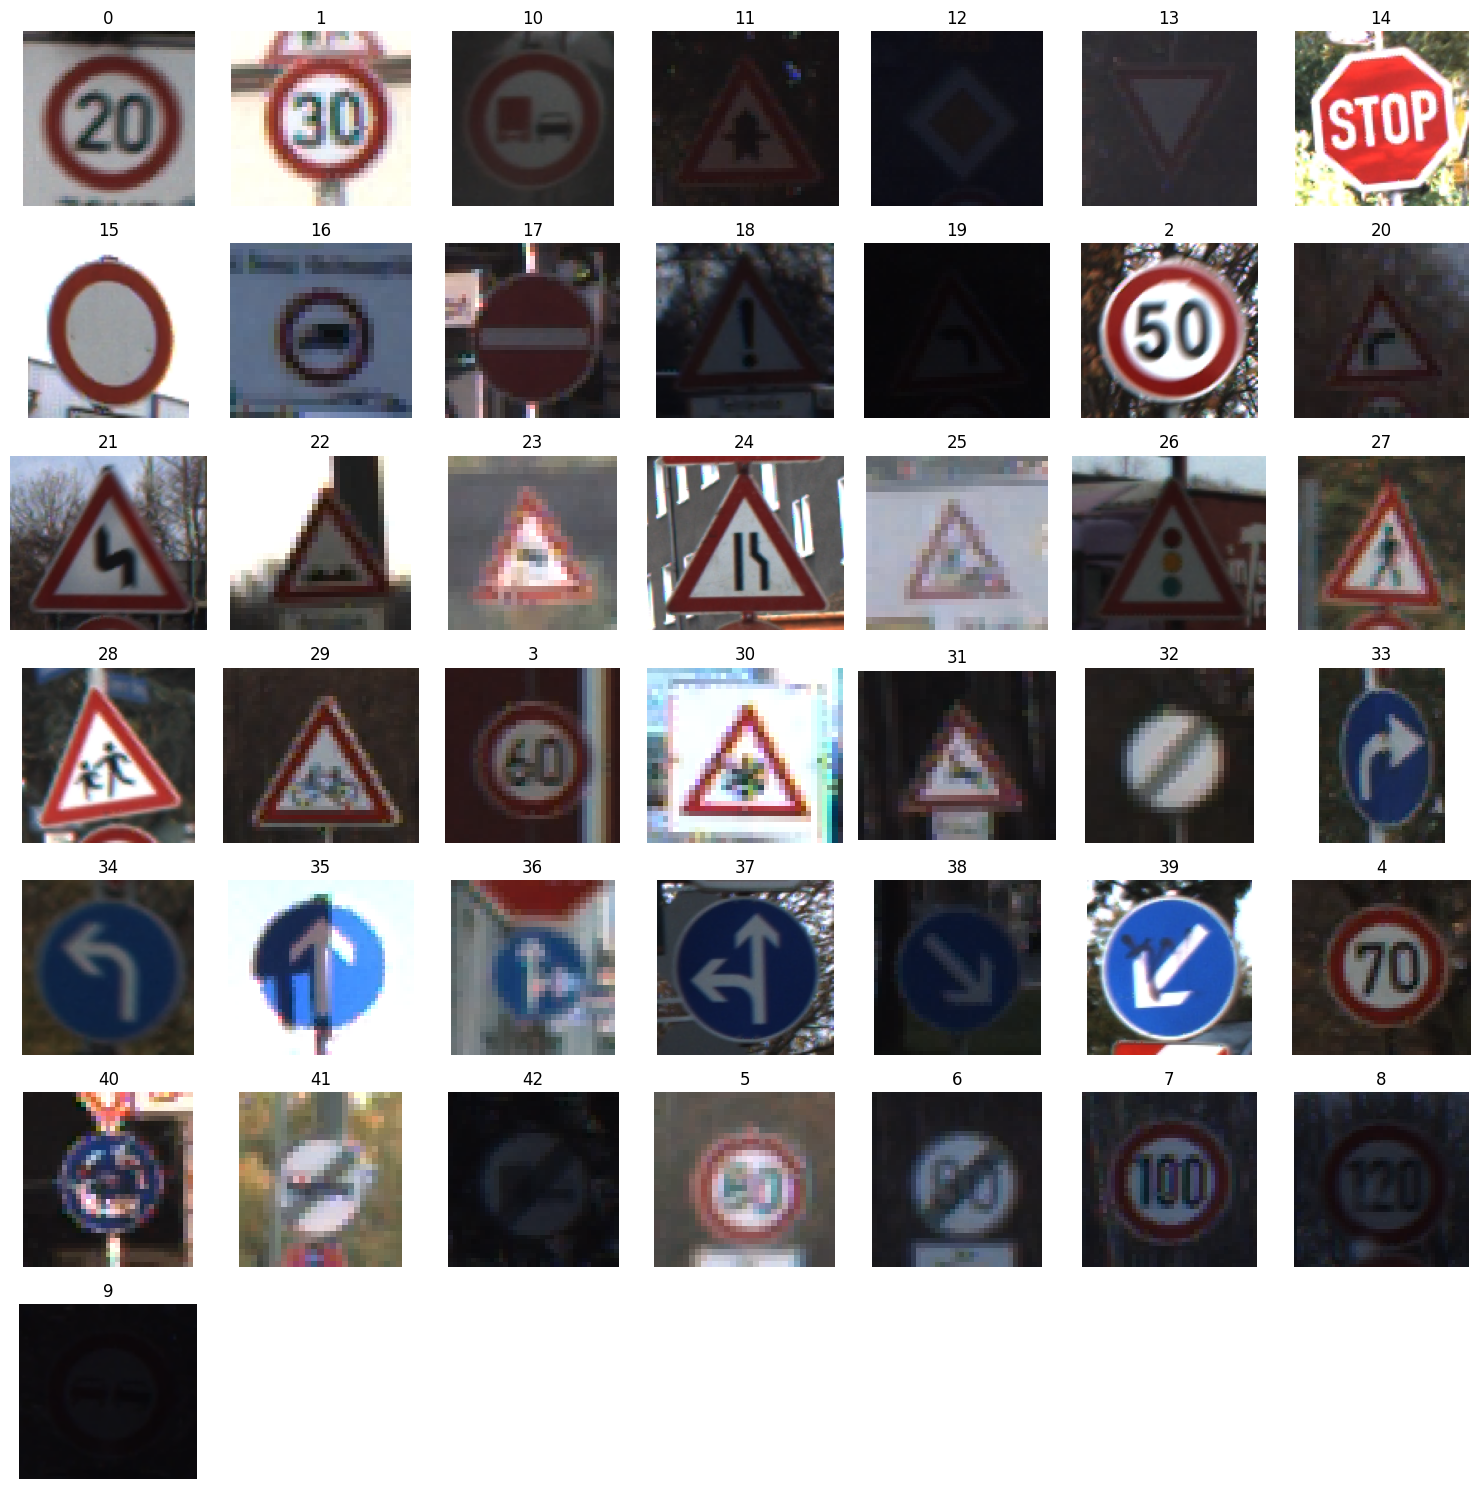

In [ ]:
import cv2
import matplotlib.pyplot as plt

train_path = r"/content/archive_dataset/train"

plt.figure(figsize=(15, 15))

for i, class_name in enumerate(sorted(os.listdir(train_path))):

    class_path = os.path.join(train_path, class_name)

    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)

    img_name = random.choice(images)
    img_path = os.path.join(class_path, img_name)

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    print(f"Class {class_name} -> Shape: {img.shape}")

    plt.subplot(7, 7, i+1)
    plt.imshow(img_rgb)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Applying Data Augmentation

In this step, we manually apply basic data augmentation techniques to a sample image.  
The goal is to understand how transformations can modify the image while preserving its meaning.

The following augmentations are applied:
- **Rotation (15°)**: simulates different viewing angles  
- **Grayscale conversion**: removes color information and focuses on shape  

This helps illustrate how models become more robust to variations in real-world scenarios.

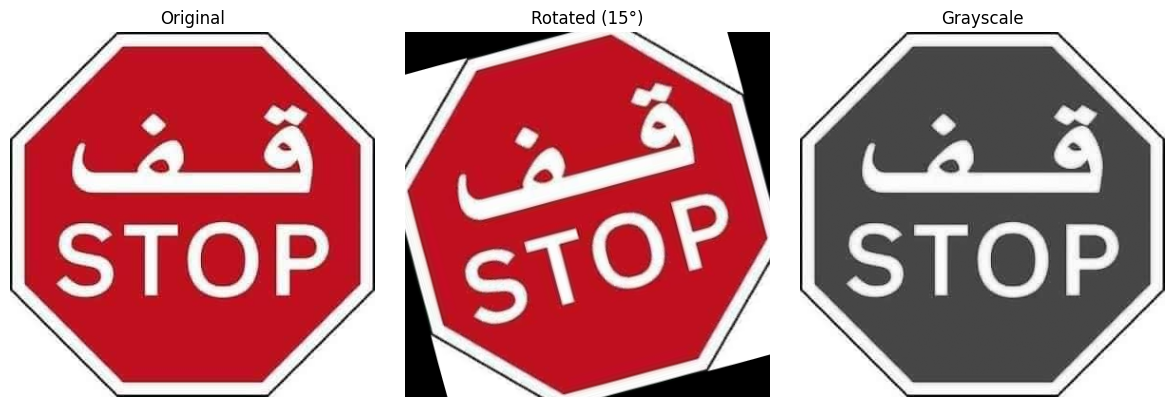

In [10]:
import cv2
import matplotlib.pyplot as plt

img_path = r"/content/stop.jpg"

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


(h, w) = img.shape[:2]
center = (w // 2, h // 2)

matrix = cv2.getRotationMatrix2D(center, 15, 1.0)
rotated = cv2.warpAffine(img_rgb, matrix, (w, h))


gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)


plt.figure(figsize=(12, 4))

# Original
plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis('off')

# Rotated
plt.subplot(1, 3, 2)
plt.imshow(rotated)
plt.title("Rotated (15°)")
plt.axis('off')

# Grayscale
plt.subplot(1, 3, 3)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis('off')

plt.tight_layout()
plt.show()

## Installing Required Library

In this step, we install the Ultralytics library, which provides the implementation of YOLOv8 models.  
This library is essential for training, evaluating, and performing inference using the YOLOv8 framework.

In [ ]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.5 MB/s eta 0:00:00


## Initializing the YOLOv8 Classification Model

In this step, we load a pre-trained YOLOv8 Nano classification model.  
This approach is known as **Transfer Learning**, where a model trained on a large dataset is reused and fine-tuned for a new task.

Using a pre-trained model helps:
- Reduce training time  
- Improve performance  
- Achieve better results with less data

In [12]:
from ultralytics import YOLO

model = YOLO('yolov8n-cls.pt')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Training the YOLOv8 Classification Model

In this step, we train the YOLOv8 Nano classification model on our prepared dataset.  
The model learns to classify traffic signs based on the images provided in the training set.

Key parameters used:
- **data**: Path to the dataset (organized into train and validation folders)  
- **epochs**: Number of training iterations  
- **imgsz**: Input image size (images are resized to 224×224)

During training, the model optimizes its weights to minimize loss and improve classification accuracy.

In [13]:
from ultralytics import YOLO

model = YOLO('yolov8n-cls.pt')

model.train(
    data=r"/content/archive_dataset",
    epochs=10,
    imgsz=224
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/archive_dataset, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, 

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e08df1003b0>
curves: []
curves_results: []
fitness: 0.996748298406601
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.9936240911483765, 'metrics/accuracy_top5': 0.9998725056648254, 'fitness': 0.996748298406601}
save_dir: PosixPath('/content/runs/classify/train')
speed: {'preprocess': 0.11594851071153024, 'inference': 0.45375811591394816, 'loss': 0.0011497397349308663, 'postprocess': 0.0011997384604841962}
top1: 0.9936240911483765
top5: 0.9998725056648254

## Evaluating Model Performance: Confusion Matrix

In this step, we visualize the confusion matrix generated after training.  
The confusion matrix provides a detailed view of the model's performance by showing how predictions are distributed across all classes.

- Correct predictions appear along the diagonal  
- Misclassifications appear outside the diagonal  

This helps identify which classes the model confuses and where improvements may be needed.

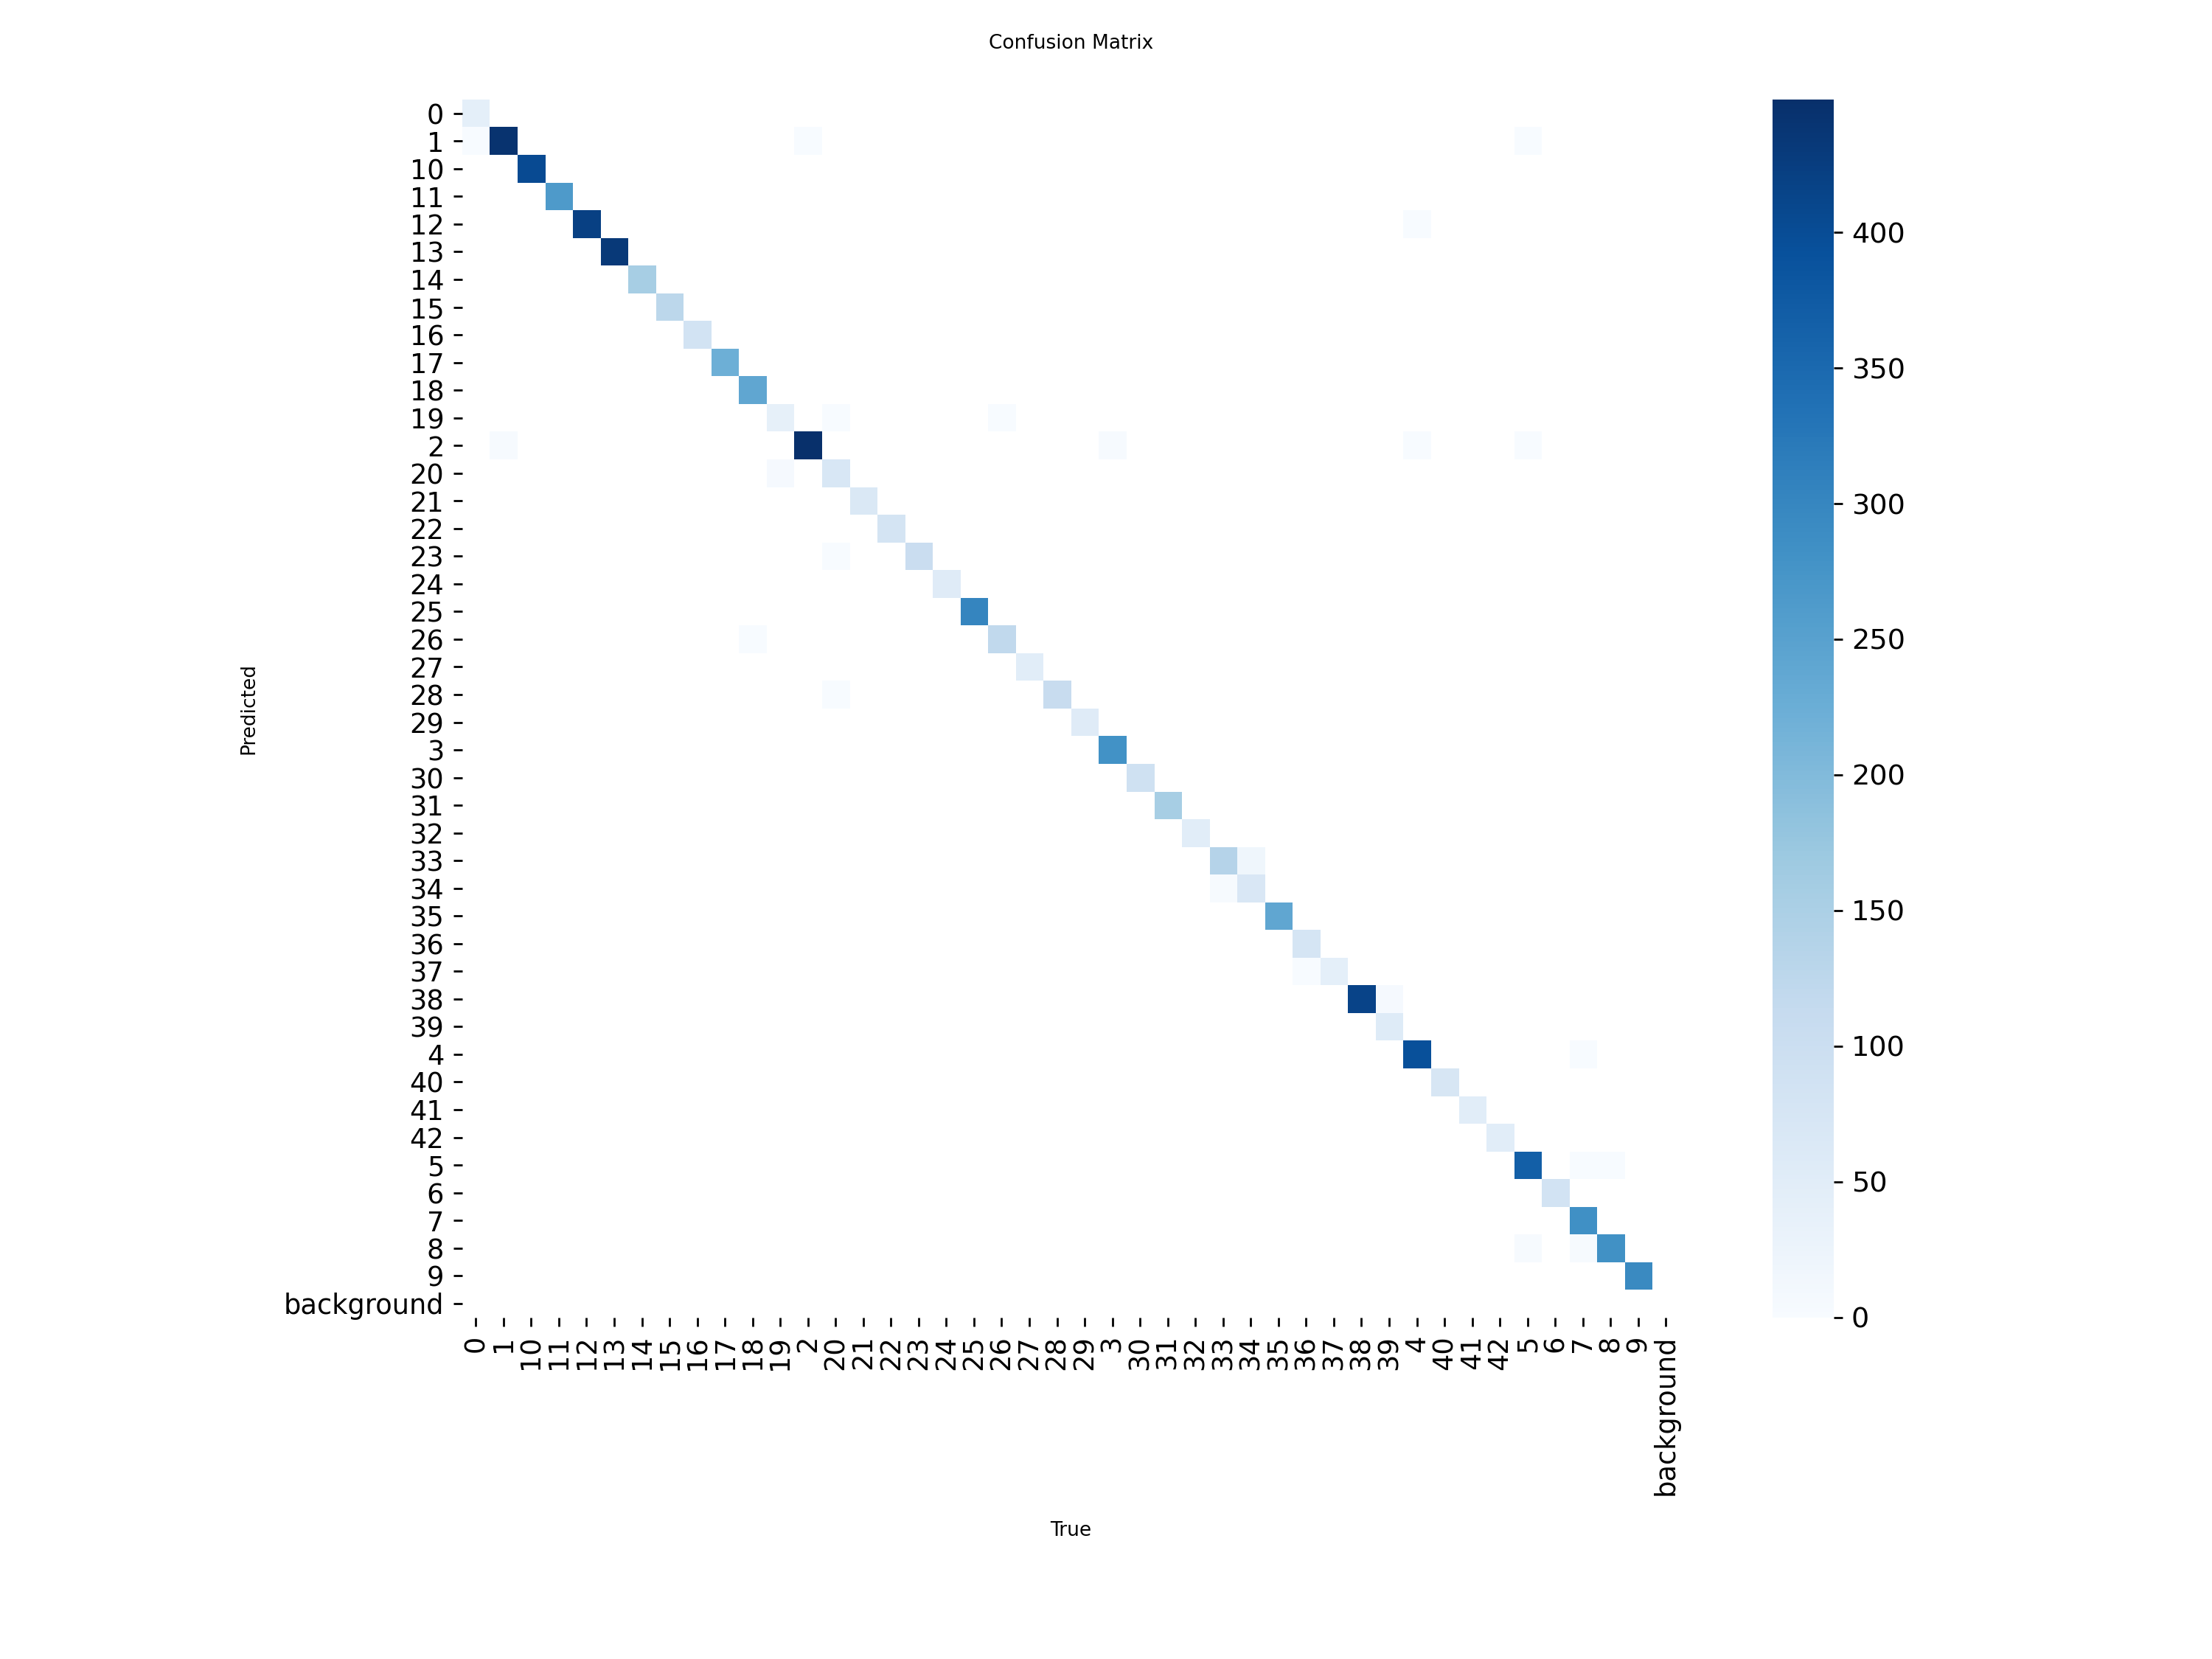

In [18]:
from IPython.display import Image, display

display(Image(filename="/content/runs/classify/train/confusion_matrix.png"))


## Training Results Visualization

In this step, we visualize the training results, which include performance metrics such as loss and accuracy over epochs.

These plots help us understand how the model improved during training:
- **Loss curve**: should decrease over time  
- **Accuracy curve**: should increase over time  

This allows us to evaluate whether the model is learning effectively and check for issues like overfitting or underfitting.

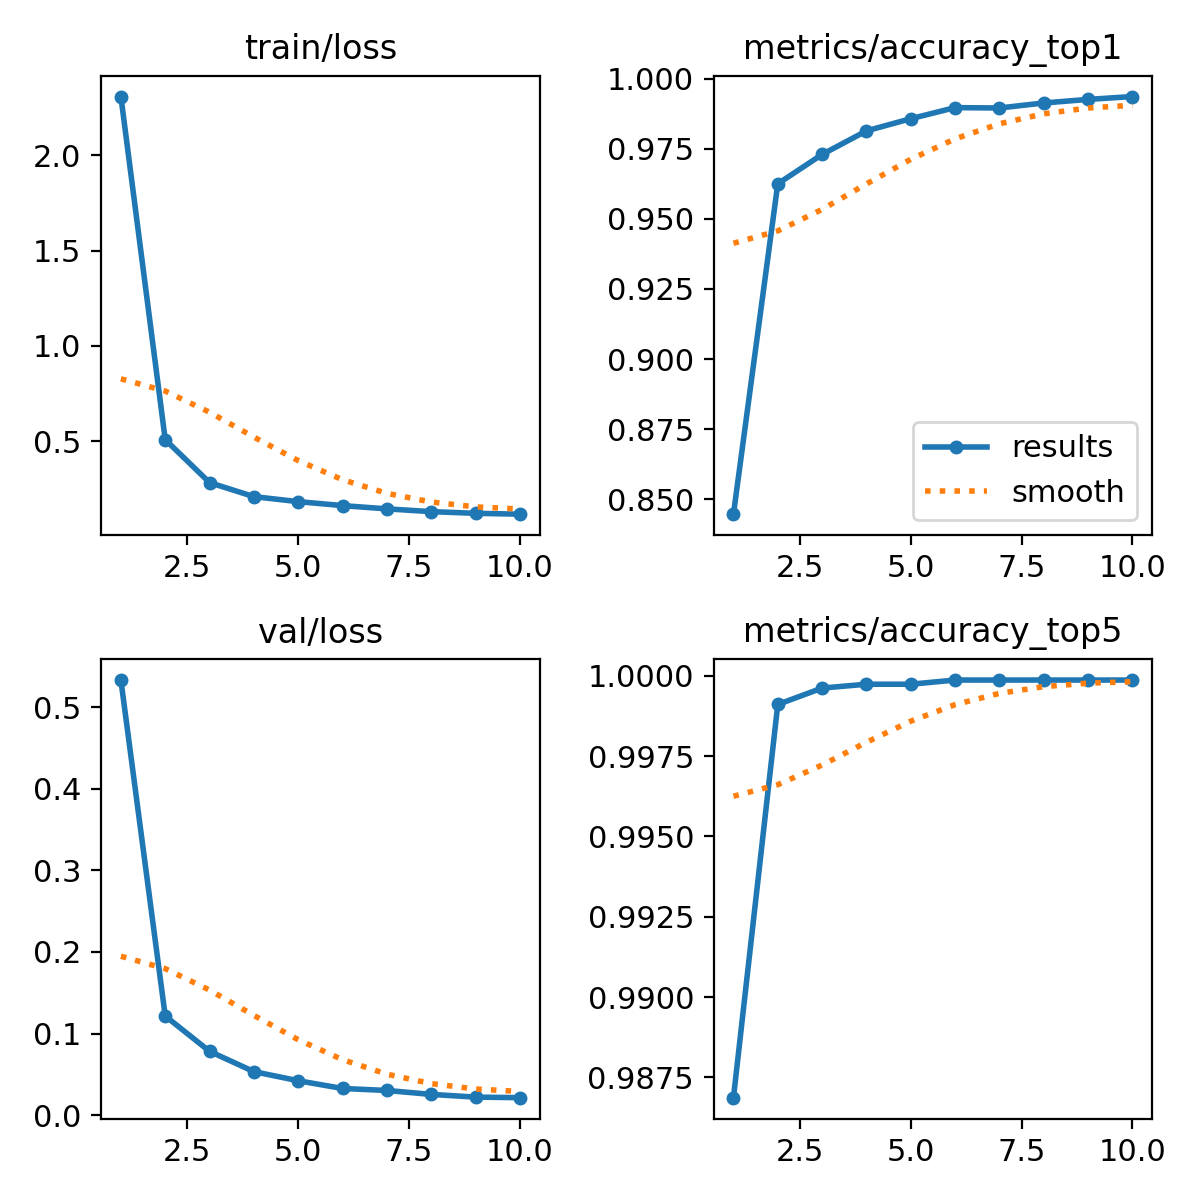

In [19]:
display(Image(filename="/content/runs/classify/train/results.png"))

## Model Evaluation Metrics

In this step, we evaluate the trained model using the validation dataset.  
The model returns key performance metrics that summarize its classification accuracy.

The most important metrics are:
- **Top-1 Accuracy**: Percentage of correct predictions where the model's first choice is correct  
- **Top-5 Accuracy**: Percentage where the correct label is within the top 5 predictions  

These metrics provide a quantitative measure of the model's performance.

In [15]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,489,963 parameters, 0 gradients, 3.3 GFLOPs
train: /content/archive_dataset/train... found 31367 images in 43 classes ✅ 
val: /content/archive_dataset/val... found 7842 images in 43 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 198.4±156.0 MB/s, size: 5.2 KB)
val: Scanning /content/archive_dataset/val... 7842 images, 0 corrupt: 100% ━━━━━━━━━━━━ 7842/7842 1.7Git/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 491/491 25.4it/s 19.4s
                   all      0.994          1
Speed: 0.1ms preprocess, 0.9ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val
ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e08beab8aa0>
curves: []
curves_results: []
fitness: 0.9968120455741882
keys

## Downloading the Trained Model

In this step, we download the best-performing trained model (`best.pt`) from the Colab environment to our local machine.

This allows us to:
- Reuse the model later without retraining  
- Deploy the model in real-world applications  
- Share the model with others  

In [17]:
from google.colab import files
files.download('/content/runs/classify/train/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Model Inference on a New Image

In this step, we test the trained model on a completely new image that was not part of the training dataset.  
This process is called **inference** and is used to evaluate how well the model generalizes to unseen data.

The model predicts:
- The class index  
- The corresponding traffic sign label  
- The confidence score of the prediction  

To ensure correct interpretation, we map the model's output to the actual class labels using a predefined class dictionary.


image 1/1 /content/stop.jpg: 224x224 14 0.98, 29 0.01, 18 0.00, 13 0.00, 25 0.00, 8.6ms
Speed: 5.4ms preprocess, 8.6ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Model Index: 6
Folder Name (Real ID): 14
Final Description: Stop
Confidence: 0.9783


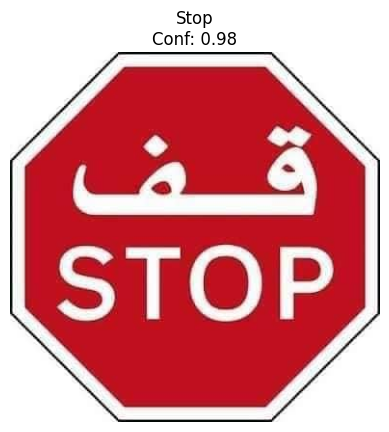

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt


model = YOLO("/content/runs/classify/train/weights/best.pt")

class_map = {
    0:'Speed limit (20km/h)', 1:'Speed limit (30km/h)', 2:'Speed limit (50km/h)',
    3:'Speed limit (60km/h)', 4:'Speed limit (70km/h)', 5:'Speed limit (80km/h)',
    6:'End of speed limit (80km/h)', 7:'Speed limit (100km/h)', 8:'Speed limit (120km/h)',
    9:'No passing', 10:'No passing veh over 3.5 tons', 11:'Right-of-way at intersection',
    12:'Priority road', 13:'Yield', 14:'Stop', 15:'No vehicles',
    16:'Veh > 3.5 tons prohibited', 17:'No entry', 18:'General caution',
    19:'Dangerous curve left', 20:'Dangerous curve right', 21:'Double curve',
    22:'Bumpy road', 23:'Slippery road', 24:'Road narrows on the right',
    25:'Road work', 26:'Traffic signals', 27:'Pedestrians',
    28:'Children crossing', 29:'Bicycles crossing', 30:'Beware of ice/snow',
    31:'Wild animals crossing', 32:'End speed + passing limits',
    33:'Turn right ahead', 34:'Turn left ahead', 35:'Ahead only',
    36:'Go straight or right', 37:'Go straight or left', 38:'Keep right',
    39:'Keep left', 40:'Roundabout mandatory', 41:'End of no passing',
    42:'End no passing veh > 3.5 tons'
}

img_path = "/content/stop.jpg"
results = model.predict(img_path)

pred_index = results[0].probs.top1
confidence = results[0].probs.top1conf.item()

folder_name = model.names[pred_index]

real_class_id = int(folder_name)
full_name = class_map[real_class_id]

print(f"Model Index: {pred_index}")
print(f"Folder Name (Real ID): {real_class_id}")
print(f"Final Description: {full_name}")
print(f"Confidence: {confidence:.4f}")

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.title(f"{full_name}\nConf: {confidence:.2f}")
plt.axis("off")
plt.show()

# 1. How does feeding data into a model change when you move from tabular data (like the pumpkin prices) to image data? 

When working with tabular data (such as pumpkin prices), the input to the model consists of structured numerical or categorical values organized in rows and columns. Each feature has a clear meaning (e.g., price, size, weight), and preprocessing typically involves scaling, encoding, and handling missing values.

In contrast, image data is unstructured and consists of pixel values arranged in multi-dimensional arrays (height × width × channels). Instead of manually defined features, deep learning models automatically extract features such as edges, shapes, and patterns. Additionally, images must be resized and normalized before being fed into neural networks.

# 2. Why is data augmentation (like rotating or changing the brightness of images) a crucial step in computer vision?

Data augmentation is crucial in computer vision because it artificially increases the diversity of the dataset without collecting new data.

Techniques such as rotation, flipping, zooming, and brightness adjustment help the model generalize better.
This is important because, in real-world scenarios, objects may appear under different angles, lighting conditions, and backgrounds. 

Without augmentation, the model may overfit to the training data and fail when encountering new variations. 
Therefore, augmentation improves robustness and reduces overfitting.

# 3. When testing your new image from the internet, what confidence score (probability) did the model give its prediction? What does a low confidence score tell you about the model's limits? 

When testing the model on a new image from the internet, the model predicted the class "Stop" with a confidence score of approximately 0.978 (97.8%).

A high confidence score indicates that the model is very certain about its prediction. On the other hand, a low confidence score suggests that the model is uncertain, which may happen when:
- The image is unclear or noisy
- The object differs from the training data distribution
- The model has not seen similar examples before

Therefore, low confidence highlights the limitations of the model and indicates that further training or more diverse data may be required.